In [1]:
!nvidia-smi

Thu Jul 13 04:33:19 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 525.105.17   Driver Version: 525.105.17   CUDA Version: 12.0     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |
| N/A   66C    P8    14W /  70W |      0MiB / 15360MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [2]:
!pip install ultralytics==8.0.20

from IPython import display
display.clear_output()

import ultralytics
ultralytics.checks()

Ultralytics YOLOv8.0.20 🚀 Python-3.10.12 torch-2.0.1+cu118 CUDA:0 (Tesla T4, 15102MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 24.2/78.2 GB disk)


In [3]:
from ultralytics import YOLO

from IPython.display import display, Image

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
%cd /content/drive/MyDrive/detection-oil-storage

/content/drive/MyDrive/detection-oil-storage


In [7]:
!ls

config	data  detection-oil-tank.ipynb	detection-oil-tank-train.ipynb


In [10]:
%cd /content/drive/MyDrive/detection-oil-storage

!yolo task=detect mode=train model=yolov8m.pt data=/content/drive/MyDrive/detection-oil-storage/config/data.yaml epochs=25 imgsz=512 plots=True

/content/drive/MyDrive/detection-oil-storage
Ultralytics YOLOv8.0.20 🚀 Python-3.10.12 torch-2.0.1+cu118 CUDA:0 (Tesla T4, 15102MiB)
yolo/engine/trainer: task=detect, mode=train, model=yolov8m.yaml, data=/content/drive/MyDrive/detection-oil-storage/config/data.yaml, epochs=25, patience=50, batch=16, imgsz=512, save=True, cache=False, device=, workers=8, project=None, name=None, exist_ok=False, pretrained=False, optimizer=SGD, verbose=True, seed=0, deterministic=True, single_cls=False, image_weights=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, overlap_mask=True, mask_ratio=4, dropout=False, val=True, save_json=False, save_hybrid=False, conf=0.001, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=ultralytics/assets/, show=False, save_txt=False, save_conf=False, save_crop=False, hide_labels=False, hide_conf=False, vid_stride=1, line_thickness=3, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, boxes=True, format=torchsc

In [11]:
!ls runs/detect/train/

args.yaml					    train_batch1.jpg
confusion_matrix.png				    train_batch2.jpg
events.out.tfevents.1689223591.131c8052d574.3883.0  train_batch390.jpg
F1_curve.png					    train_batch391.jpg
P_curve.png					    train_batch392.jpg
PR_curve.png					    val_batch0_labels.jpg
R_curve.png					    val_batch0_pred.jpg
results.csv					    val_batch1_labels.jpg
results.png					    val_batch1_pred.jpg
train_batch0.jpg				    weights


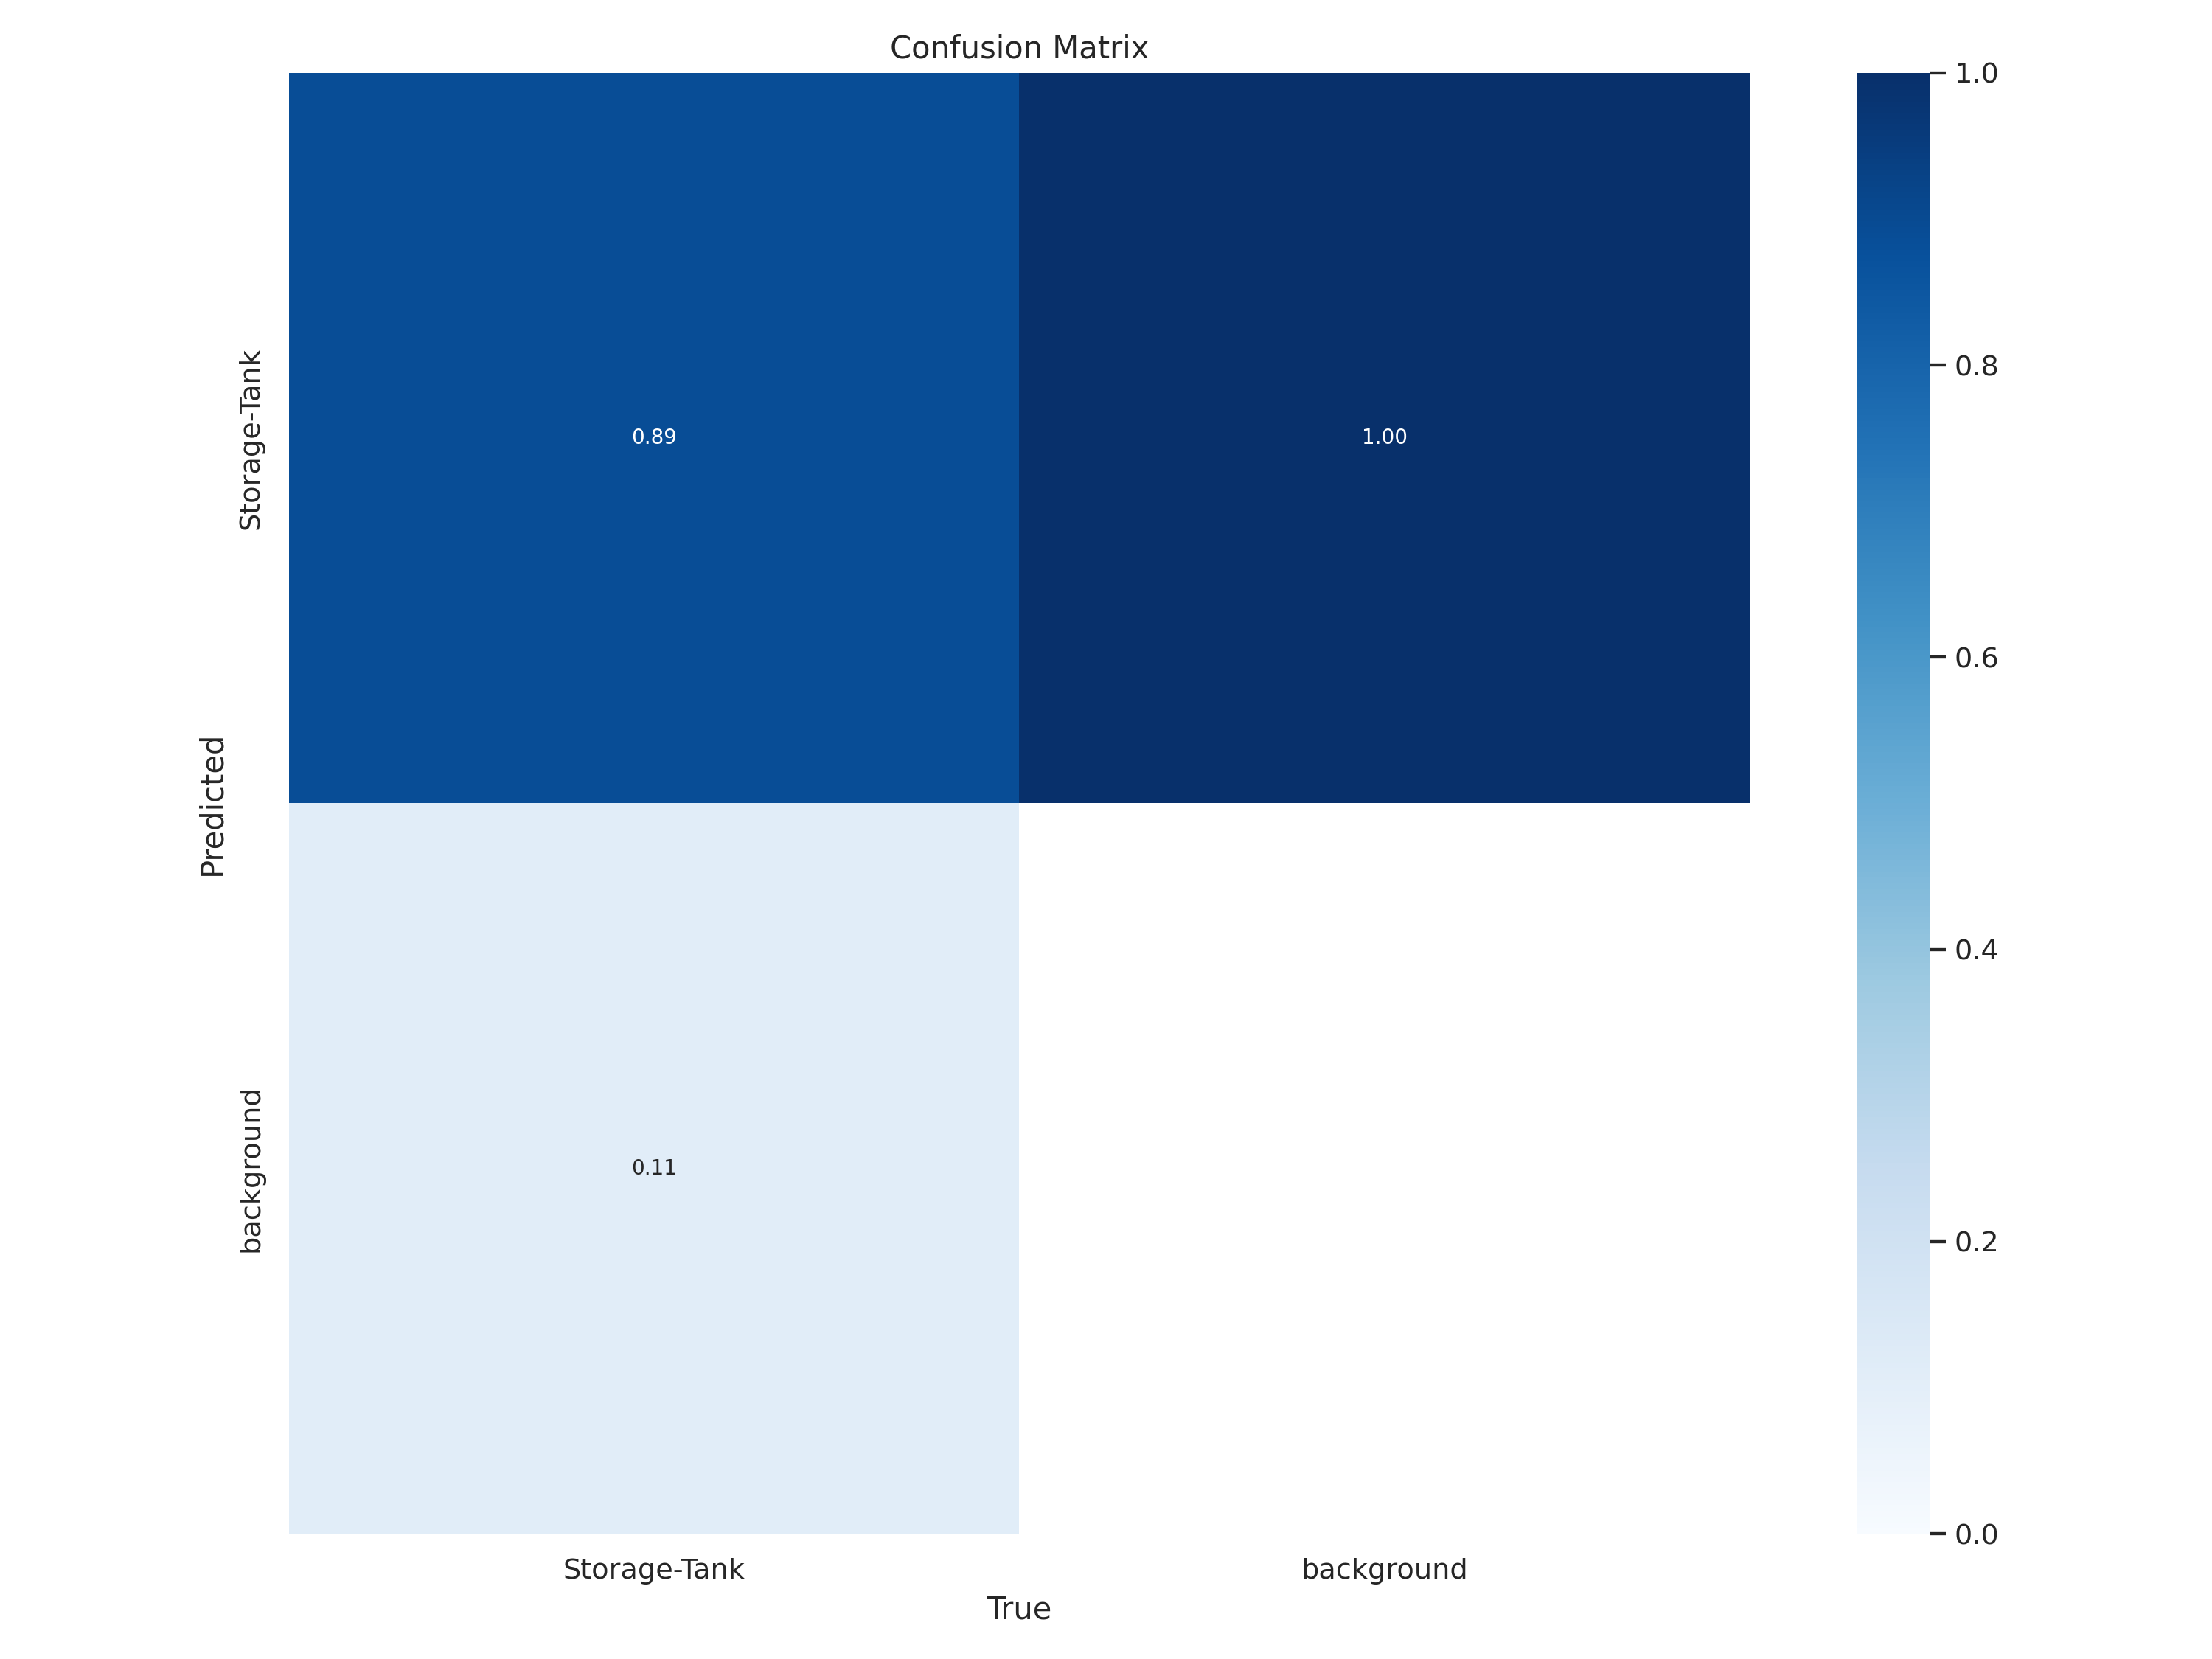

In [13]:
Image(filename='runs/detect/train/confusion_matrix.png', width=800)

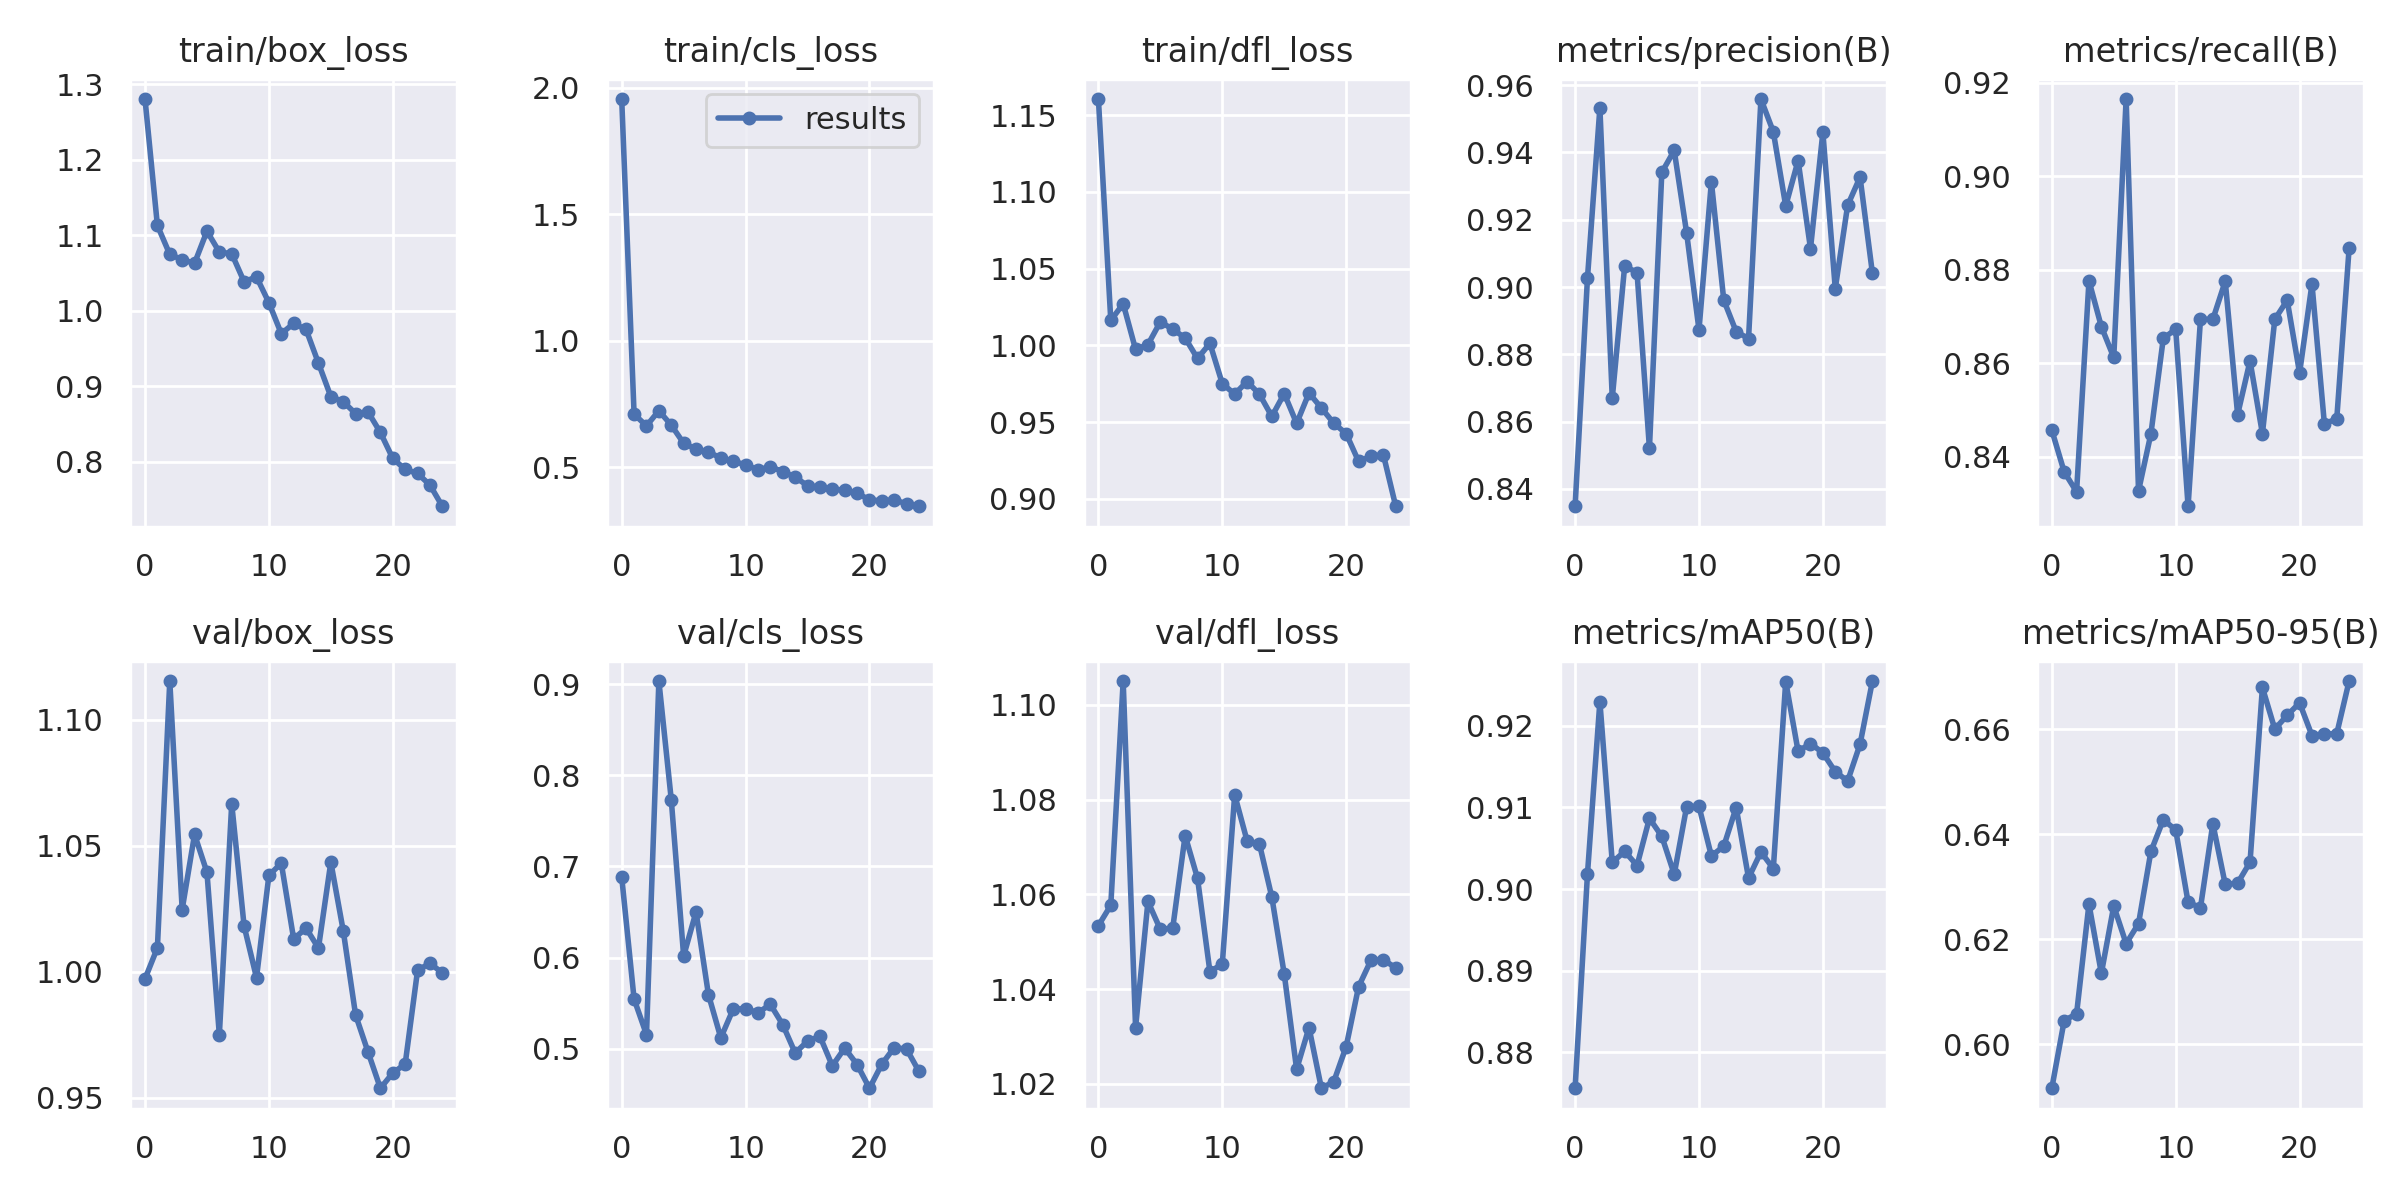

In [14]:
Image(filename='runs/detect/train/results.png', width=800)

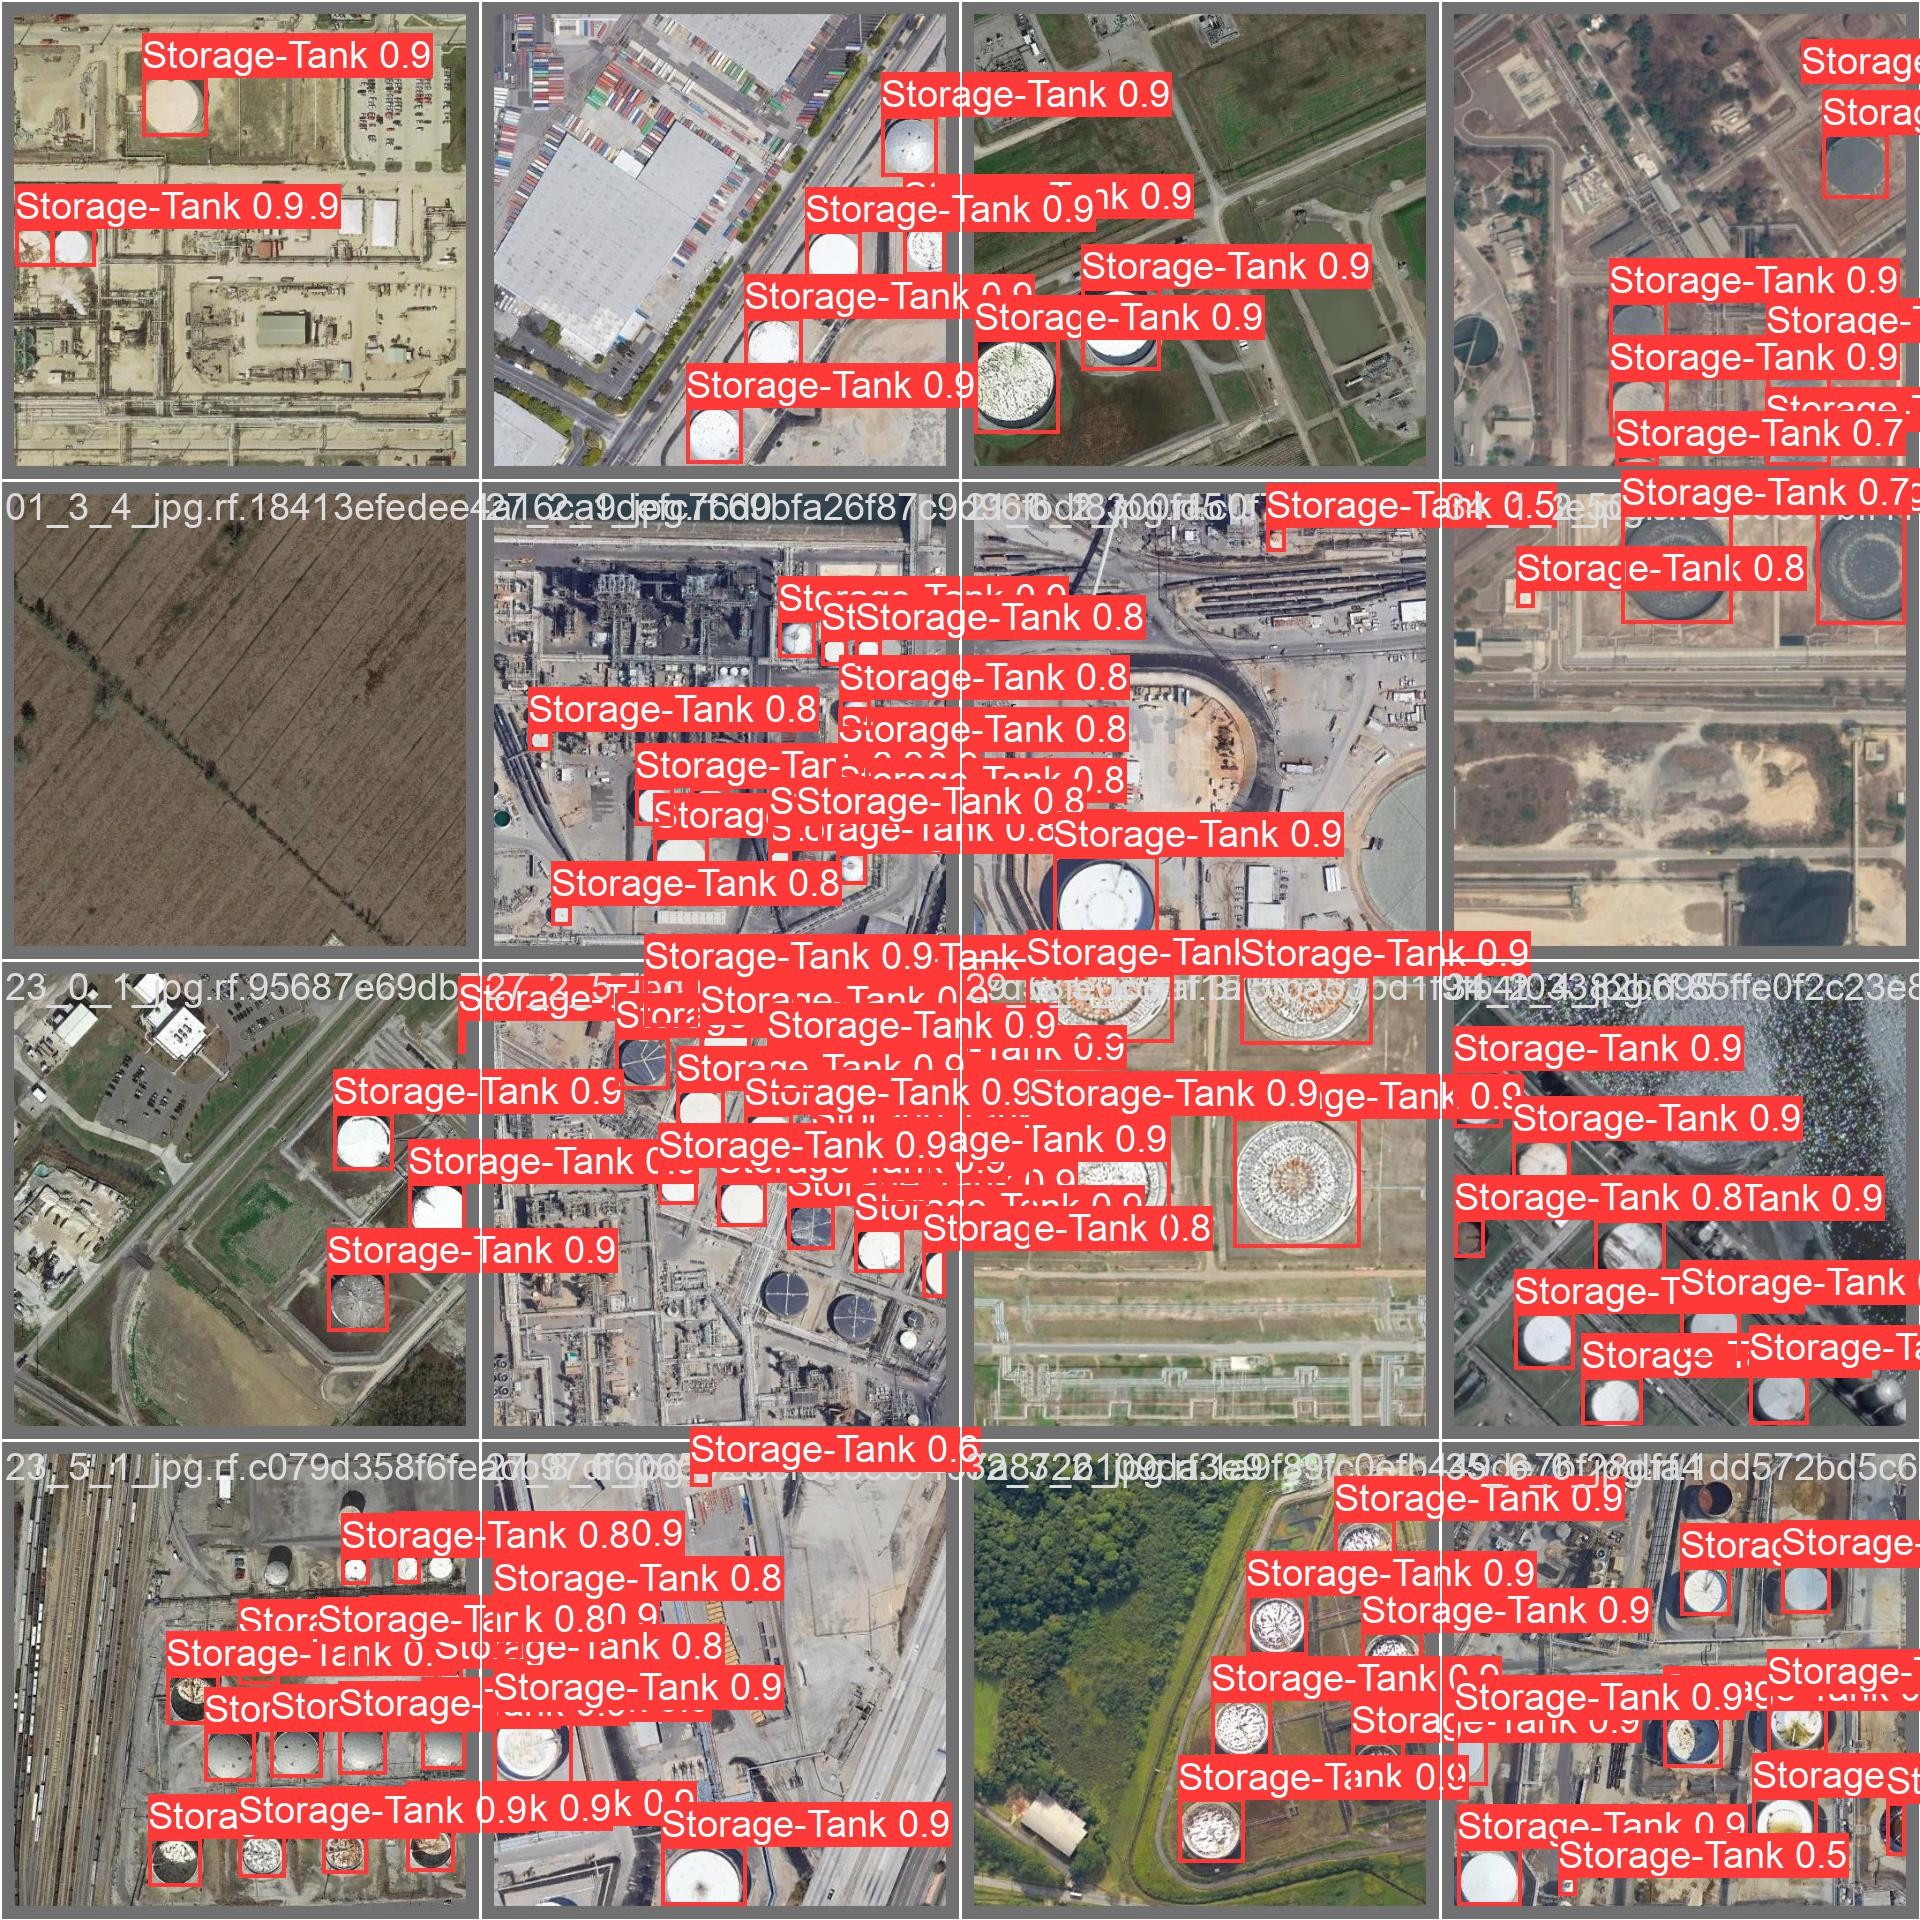

In [16]:
Image(filename='runs/detect/train/val_batch0_pred.jpg', width=800)

In [19]:
!yolo task=detect mode=val model=runs/detect/train/weights/best.pt data=/content/drive/MyDrive/detection-oil-storage/config/data.yaml

2023-07-13 05:13:07.525073: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-07-13 05:13:08.368526: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
Ultralytics YOLOv8.0.20 🚀 Python-3.10.12 torch-2.0.1+cu118 CUDA:0 (Tesla T4, 15102MiB)
Model summary (fused): 218 layers, 25840339 parameters, 0 gradients, 78.7 GFLOPs
val: Scanning /content/drive/MyDrive/detection-oil-storage/data/valid/labels.cache... 40 images, 6 backgrounds, 0 corrupt: 100% 40/40 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 3/3 [00:03<00:00,  1.08s/it]
                   all         40        245      0.904      0.885      0.923       0.67
Speed: 1.5ms pre-process

In [21]:
!yolo task=detect mode=predict model=runs/detect/train/weights/best.pt data=/content/drive/MyDrive/detection-oil-storage/config/data.yaml conf=0.25 source=data/test/images save=True

2023-07-13 05:17:06.687896: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-07-13 05:17:07.962036: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
Ultralytics YOLOv8.0.20 🚀 Python-3.10.12 torch-2.0.1+cu118 CUDA:0 (Tesla T4, 15102MiB)
Model summary (fused): 218 layers, 25840339 parameters, 0 gradients, 78.7 GFLOPs
image 1/20 /content/drive/MyDrive/detection-oil-storage/data/test/images/01_2_4_jpg.rf.e19df7c2fa64bbed0b0afdb7b0739e53.jpg: 512x512 2 Storage-Tanks, 25.4ms
image 2/20 /content/drive/MyDrive/detection-oil-storage/data/test/images/01_2_6_jpg.rf.bc9ab2f1be03147c763ee51a0372955f.jpg: 512x512 2 Storage-Tanks, 25.4ms
image 3/20 /content/drive/MyDrive/detection-oil-storage/data/test/images/0